In [1]:
!pip install git+https://github.com/mimoralea/gym-bandits#egg=gym-bandits
!pip install git+https://github.com/mimoralea/gym-walk#egg=gym-walk

  Cloning https://github.com/mimoralea/gym-bandits to /tmp/pip-install-ezo21s4f/gym-bandits_44ee7101f5634f1792d8de5b26dc6830
  Running command git clone --filter=blob:none --quiet https://github.com/mimoralea/gym-bandits /tmp/pip-install-ezo21s4f/gym-bandits_44ee7101f5634f1792d8de5b26dc6830
  Resolved https://github.com/mimoralea/gym-bandits to commit f4b45d39e59eee3f6377ceb42466749af2cd77bd
  Preparing metadata (setup.py) ... done
  Cloning https://github.com/mimoralea/gym-walk to /tmp/pip-install-x5t7hktf/gym-walk_1b1ef5f497b447c7839d47347f5a15fc
  Running command git clone --filter=blob:none --quiet https://github.com/mimoralea/gym-walk /tmp/pip-install-x5t7hktf/gym-walk_1b1ef5f497b447c7839d47347f5a15fc
  Resolved https://github.com/mimoralea/gym-walk to commit b915b94cf2ad16f8833a1ad92ea94e88159279f5
  Preparing metadata (setup.py) ... done


In [15]:
import numpy as np
import gymnasium as gym

import warnings ; warnings.filterwarnings('ignore')

from pprint import pprint
# from tqdm import tqdm_notebook as tqdm
from tqdm.notebook import tqdm

from itertools import cycle

import random

np.set_printoptions(suppress=True)
random.seed(123); np.random.seed(123)
SEEDS = (12, 34, 56, 78, 90)



In [3]:
import gym_bandits
import gym
env = gym.make("BanditTenArmedGaussian-v0")
env.reset()

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.12/dist-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.12/dist-pack

0

/tmp/ipython-input-724028785.py:6: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for i in tqdm( range (100000)):


  0%|          | 0/100000 [00:00<?, ?it/s]

(array([   14.,    69.,   253.,   697.,  1833.,  4061.,  7533., 11310.,
        14926., 16747., 15435., 11896.,  7868.,  4215.,  1991.,   800.,
          254.,    79.,    13.,     6.]),
 array([-3.64119165, -3.22348523, -2.80577882, -2.38807241, -1.97036599,
        -1.55265958, -1.13495317, -0.71724676, -0.29954034,  0.11816607,
         0.53587248,  0.9535789 ,  1.37128531,  1.78899172,  2.20669814,
         2.62440455,  3.04211096,  3.45981737,  3.87752379,  4.2952302 ,
         4.71293661]),
 <BarContainer object of 20 artists>)

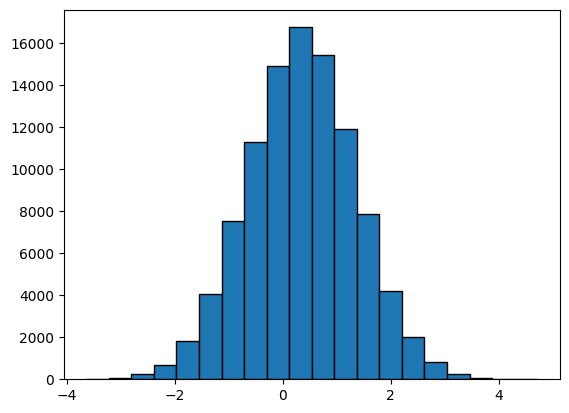

In [5]:
Q = np.zeros((env.action_space.n))
action = np.argmax(Q)

_, reward, _ , _ = env.step(action)
rewards=[]
for i in tqdm( range (100000)):
  _, reward, _ , _ = env.step(action)
  rewards.append(reward)

## distribution of rewards for many iterations

import matplotlib.pyplot as plt

plt.hist(rewards, edgecolor='black', bins=20)

In [6]:
print(env.env.r_dist)
print(env.env.p_dist)

[[0.345584192064786, 1], [0.8216181435011584, 1], [0.33043707618338714, 1], [-1.303157231604361, 1], [0.9053558666731177, 1], [0.4463745723640113, 1], [-0.5369532353602852, 1], [0.5811181041963531, 1], [0.36457239618607573, 1], [0.294132496655526, 1]]
[1 1 1 1 1 1 1 1 1 1]


In [7]:
b10_Vs = []
for seed in SEEDS:
    env_name = 'BanditTenArmedGaussian-v0'
    env = gym.make(env_name, seed=seed) ; env.reset()
    r_dist = np.array(env.env.r_dist)[:,0]
    b10_Q = np.array(env.env.p_dist * r_dist)

    print('10-Armed Bandit environment with seed', seed)
    ## reward always pays out --> so prob of getting reward is always 1
    print('Probability of reward:', env.env.p_dist)
    ## reward values will change as per the seed
    print('Reward:', r_dist)

    print('Q(.):', b10_Q)

    b10_Vs.append(np.max(b10_Q))

    print('V*:', b10_Vs[-1])

    print()
print('Mean V* across all seeds:', np.mean(b10_Vs))

10-Armed Bandit environment with seed 12
Probability of reward: [1 1 1 1 1 1 1 1 1 1]
Reward: [-0.00682678  1.04614329  0.74158842  0.72395654  1.61877622 -1.20555814
 -0.62695547 -1.32066321 -0.10775251  0.99876366]
Q(.): [-0.00682678  1.04614329  0.74158842  0.72395654  1.61877622 -1.20555814
 -0.62695547 -1.32066321 -0.10775251  0.99876366]
V*: 1.6187762233340763

10-Armed Bandit environment with seed 34
Probability of reward: [1 1 1 1 1 1 1 1 1 1]
Reward: [-0.03992466 -1.25773672  2.57402319  0.48179798  0.64354662 -0.20792668
  0.05828708  0.33674264  0.19510709 -0.60931449]
Q(.): [-0.03992466 -1.25773672  2.57402319  0.48179798  0.64354662 -0.20792668
  0.05828708  0.33674264  0.19510709 -0.60931449]
V*: 2.574023189963745

10-Armed Bandit environment with seed 56
Probability of reward: [1 1 1 1 1 1 1 1 1 1]
Reward: [-0.84994072  0.32194085  1.78904286  0.8793392   0.37159282  1.48769378
  0.72866553  2.08124873 -1.33726808  0.12535155]
Q(.): [-0.84994072  0.32194085  1.78904286  

## Pure exploitation


In [18]:
def pure_exploit(env, n_episodes=5000):
  Q =np.zeros((env.action_space.n))
  N =np.zeros((env.action_space.n))

  ## storing estimates for each episodes
  Qe = np.empty((n_episodes, env.action_space.n))
  returns = np.empty(n_episodes)
  actions = np.empty(n_episodes, dtype=int)

  name = 'pure_exploitation'
  for e in tqdm(range(n_episodes), desc = "Episodes for : "+name, leave = False):
    action = np.argmax(Q)
    _, reward, _ , _ = env.step(action)
    N[action] +=1
    # print(N[action])

    Q[action] = Q[action] +(reward - Q[action])/N[action]
    # print(Q[action])

    ## storing data in the table
    Qe[e] = Q
    returns[e] =reward
    actions[e] = action

  return name, returns, Qe, actions



In [20]:
name, returns, Qe, actions= pure_exploit(env)

Episodes for : pure_exploitation:   0%|          | 0/5000 [00:00<?, ?it/s]

(array([[   0.,    0.,    0.,    0.,    0., 4994.,    3.,    1.,    1.,
            1.],
        [5000.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
            0.],
        [5000.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
            0.],
        [5000.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
            0.],
        [5000.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
            0.],
        [5000.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
            0.],
        [5000.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
            0.],
        [5000.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
            0.],
        [5000.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
            0.],
        [5000.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
            0.]]),
 array([0.        , 0.32292468, 0.64584935, 0.96877403, 1.29169871,
        1.61462339, 1.93754806, 2.260472

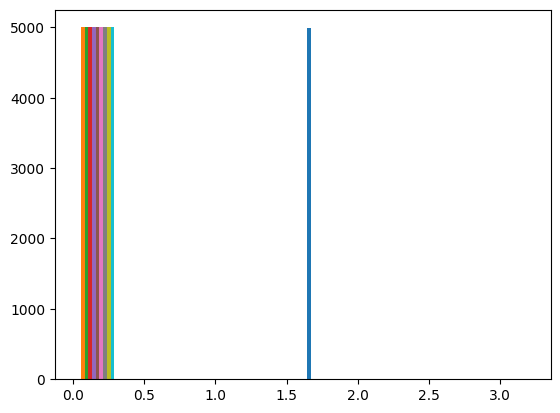

In [24]:
plt.hist(Qe)